# CNN trên PlantVillage

Bài thực hành tuần 7: Xây dựng mô hình CNN tự thiết kế (không pretrained) để phân loại bệnh trên lá cây.

**Yêu cầu:**
- Phân tích dữ liệu, xử lý mất cân bằng (38 lớp, phân bố không đều)
- Tối ưu tham số, accuracy > 90%
- Không dùng pretrained model

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from collections import Counter
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import shutil

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [19]:
# Đường dẫn đến thư mục dữ liệu gốc (color images)
# Thay đổi đường dẫn này tùy theo cách bạn tải dữ liệu
RAW_DIR = './data/plantvillage/plantvillage dataset/color'

# Nếu cấu trúc khác, thử các đường dẫn phổ biến
alt_paths = [
    './data/plantvillage/plantvillage dataset/color',
    './data/plantvillage/color',
    './data/plantvillage/PlantVillage',
    './data/plantvillage',
]

for p in alt_paths:
    if os.path.exists(p):
        subdirs = [d for d in os.listdir(p) if os.path.isdir(os.path.join(p, d)) and not d.startswith('.')]
        if len(subdirs) > 10:  # PlantVillage có 38 lớp
            RAW_DIR = p
            break

if os.path.exists(RAW_DIR):
    class_names = sorted([d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d)) and not d.startswith('.')])
    print(f'Tìm thấy {len(class_names)} lớp trong {RAW_DIR}')
    for i, cls in enumerate(class_names):
        n = len(os.listdir(os.path.join(RAW_DIR, cls)))
        print(f'  [{i:2d}] {cls}: {n} ảnh')
else:
    print(f'Chưa tìm thấy dữ liệu! Hãy tải từ Kaggle theo hướng dẫn ở trên.')

Tìm thấy 38 lớp trong ./data/plantvillage/plantvillage dataset/color
  [ 0] Apple___Apple_scab: 630 ảnh
  [ 1] Apple___Black_rot: 621 ảnh
  [ 2] Apple___Cedar_apple_rust: 275 ảnh
  [ 3] Apple___healthy: 1645 ảnh
  [ 4] Blueberry___healthy: 1502 ảnh
  [ 5] Cherry_(including_sour)___Powdery_mildew: 1052 ảnh
  [ 6] Cherry_(including_sour)___healthy: 854 ảnh
  [ 7] Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 ảnh
  [ 8] Corn_(maize)___Common_rust_: 1192 ảnh
  [ 9] Corn_(maize)___Northern_Leaf_Blight: 985 ảnh
  [10] Corn_(maize)___healthy: 1162 ảnh
  [11] Grape___Black_rot: 1180 ảnh
  [12] Grape___Esca_(Black_Measles): 1383 ảnh
  [13] Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 ảnh
  [14] Grape___healthy: 423 ảnh
  [15] Orange___Haunglongbing_(Citrus_greening): 5507 ảnh
  [16] Peach___Bacterial_spot: 2297 ảnh
  [17] Peach___healthy: 360 ảnh
  [18] Pepper,_bell___Bacterial_spot: 997 ảnh
  [19] Pepper,_bell___healthy: 1478 ảnh
  [20] Potato___Early_blight: 1000 ảnh
  [21] Pota

## 2. Chia train/test và phân tích dữ liệu

In [20]:
# Chia dữ liệu thành train (80%) và test (20%)
TRAIN_DIR = './data/plantvillage_split/train'
TEST_DIR  = './data/plantvillage_split/test'

if not os.path.exists(TRAIN_DIR):
    print('Đang chia dữ liệu train/test...')
    for cls in class_names:
        cls_dir = os.path.join(RAW_DIR, cls)
        imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        
        train_imgs, test_imgs = train_test_split(imgs, test_size=0.2, random_state=42)
        
        # Copy vào thư mục train
        os.makedirs(os.path.join(TRAIN_DIR, cls), exist_ok=True)
        for img in train_imgs:
            shutil.copy2(os.path.join(cls_dir, img), os.path.join(TRAIN_DIR, cls, img))
        
        # Copy vào thư mục test
        os.makedirs(os.path.join(TEST_DIR, cls), exist_ok=True)
        for img in test_imgs:
            shutil.copy2(os.path.join(cls_dir, img), os.path.join(TEST_DIR, cls, img))
    
    print('Chia dữ liệu xong!')
else:
    print('Dữ liệu đã được chia trước đó.')

# Đếm lại
train_classes = sorted([d for d in os.listdir(TRAIN_DIR) if not d.startswith('.')])
print(f'\nSố lớp: {len(train_classes)}')
total_train = sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in train_classes)
total_test  = sum(len(os.listdir(os.path.join(TEST_DIR, c))) for c in train_classes)
print(f'Tập train: {total_train} ảnh')
print(f'Tập test:  {total_test} ảnh')

Dữ liệu đã được chia trước đó.

Số lớp: 38
Tập train: 43429 ảnh
Tập test:  10876 ảnh


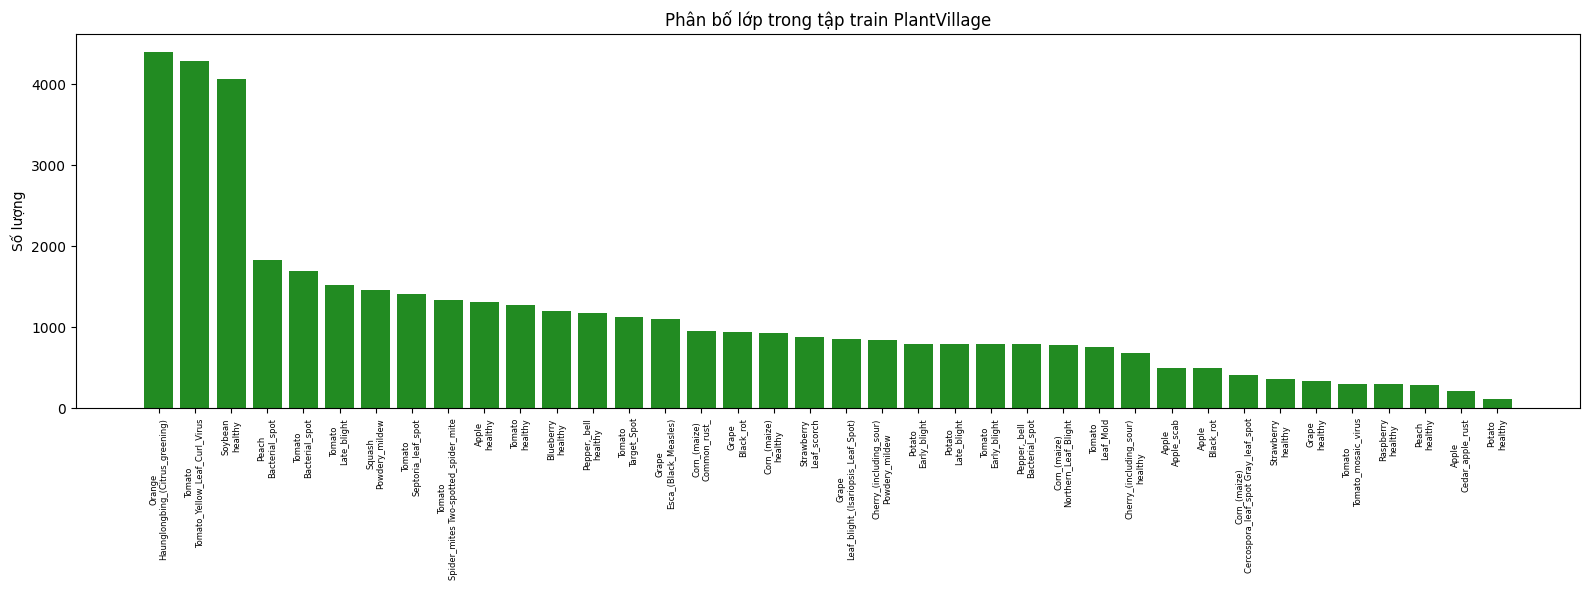

Min: 121 ảnh (Potato___healthy)
Max: 4405 ảnh (Orange___Haunglongbing_(Citrus_greening))
Tỷ lệ max/min: 36.40
=> Dữ liệu MẤT CÂN BẰNG -> sử dụng WeightedRandomSampler


In [21]:
# Phân bố lớp
train_counts = {}
for cls in train_classes:
    train_counts[cls] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))

# Sắp xếp theo số lượng
sorted_counts = dict(sorted(train_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(16, 6))
bars = plt.bar(range(len(sorted_counts)), list(sorted_counts.values()), color='forestgreen')
plt.xticks(range(len(sorted_counts)), 
           [c.replace('___', '\n') for c in sorted_counts.keys()], 
           rotation=90, fontsize=6)
plt.title('Phân bố lớp trong tập train PlantVillage')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

counts_vals = list(train_counts.values())
print(f'Min: {min(counts_vals)} ảnh ({min(train_counts, key=train_counts.get)})')
print(f'Max: {max(counts_vals)} ảnh ({max(train_counts, key=train_counts.get)})')
print(f'Tỷ lệ max/min: {max(counts_vals)/min(counts_vals):.2f}')
print(f'=> Dữ liệu MẤT CÂN BẰNG -> sử dụng WeightedRandomSampler')

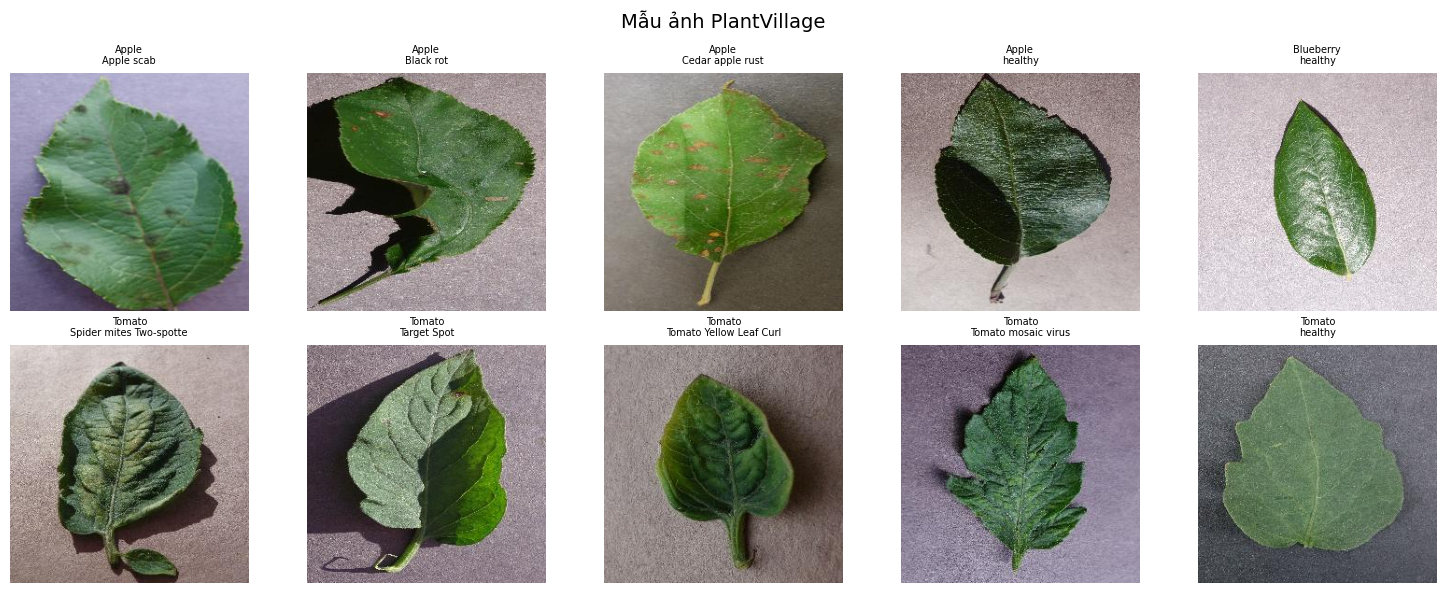

In [22]:
# Hiển thị mẫu ảnh từ một số lớp
sample_classes = train_classes[:5] + train_classes[-5:]  # 5 lớp đầu + 5 lớp cuối

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, cls in enumerate(sample_classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    img_file = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))][0]
    img = Image.open(os.path.join(cls_dir, img_file)).convert('RGB')
    
    ax = axes[idx // 5][idx % 5]
    ax.imshow(img)
    short_name = cls.replace('___', '\n').replace('_', ' ')[:30]
    ax.set_title(short_name, fontsize=7)
    ax.axis('off')

plt.suptitle('Mẫu ảnh PlantVillage', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Chuẩn bị DataLoader

In [23]:
IMG_SIZE = 64
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(root=TRAIN_DIR, transform=train_transform)
test_dataset  = ImageFolder(root=TEST_DIR, transform=test_transform)

NUM_CLASSES = len(train_dataset.classes)
print(f'Số lớp: {NUM_CLASSES}')
print(f'Train: {len(train_dataset)} ảnh')
print(f'Test:  {len(test_dataset)} ảnh')

Số lớp: 38
Train: 43429 ảnh
Test:  10876 ảnh


In [24]:
# WeightedRandomSampler cho dữ liệu mất cân bằng
targets = [s[1] for s in train_dataset.samples]
class_counts = Counter(targets)

# Weight = 1 / count (inverse frequency)
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

print(f'Batch size: {BATCH_SIZE}')
print(f'Số batch train: {len(train_loader)}')
print(f'Số batch test:  {len(test_loader)}')
print(f'\nWeightedRandomSampler được áp dụng để xử lý mất cân bằng.')

Batch size: 64
Số batch train: 679
Số batch test:  170

WeightedRandomSampler được áp dụng để xử lý mất cân bằng.


## 4. Định nghĩa mô hình CNN

In [25]:
class PlantVillage_CNN(nn.Module):
    """
    CNN tự thiết kế cho PlantVillage (không dùng pretrained).
    5 khối Conv + BatchNorm + ReLU + MaxPool + Dropout
    Global Average Pooling + FC cho 38 lớp.
    """
    def __init__(self, num_classes=38):
        super(PlantVillage_CNN, self).__init__()
        
        # Block 1: 3 -> 32, 64x64 -> 32x32
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        # Block 2: 32 -> 64, 32x32 -> 16x16
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        # Block 3: 64 -> 128, 16x16 -> 8x8
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        # Block 4: 128 -> 256, 8x8 -> 4x4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        # Block 5: 256 -> 512, 4x4 -> 2x2
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2)
        )
        # Global Average Pooling + Classifier
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = PlantVillage_CNN(num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Tổng tham số: {total_params:,}')
print(f'Số lớp đầu ra: {NUM_CLASSES}')
print()
print(model)

Tổng tham số: 4,998,342
Số lớp đầu ra: 38

PlantVillage_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2,

## 5. Huấn luyện

In [26]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total

In [27]:
EPOCHS = 40
LR = 0.001

# Dùng class weights trong loss để hỗ trợ thêm cho lớp ít mẫu
total_samples = sum(class_counts.values())
loss_weights = torch.tensor([total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
                            dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=loss_weights)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0.0

print(f'Optimizer: Adam (lr={LR}, weight_decay=1e-4)')
print(f'Loss: CrossEntropyLoss with class weights')
print(f'Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)')
print(f'Epochs: {EPOCHS}')
print('=' * 70)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    scheduler.step(test_acc)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_plantvillage_cnn.pth')
    
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:2d}/{EPOCHS}]  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
              f'Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.2f}%')

print('=' * 70)
print(f'Best Test Accuracy: {best_acc:.2f}%')

Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Loss: CrossEntropyLoss with class weights
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
Epochs: 40
Epoch [ 1/40]  Train Loss: 2.6411  Train Acc: 13.70%  Test Loss: 3.2459  Test Acc: 12.85%
Epoch [ 3/40]  Train Loss: 1.5735  Train Acc: 35.22%  Test Loss: 2.5623  Test Acc: 27.96%
Epoch [ 6/40]  Train Loss: 0.9923  Train Acc: 54.00%  Test Loss: 1.7634  Test Acc: 48.05%
Epoch [ 9/40]  Train Loss: 0.7312  Train Acc: 64.45%  Test Loss: 1.4935  Test Acc: 56.20%
Epoch [12/40]  Train Loss: 0.5710  Train Acc: 70.93%  Test Loss: 0.9129  Test Acc: 68.14%
Epoch [15/40]  Train Loss: 0.4742  Train Acc: 75.11%  Test Loss: 0.8356  Test Acc: 71.63%
Epoch [18/40]  Train Loss: 0.4276  Train Acc: 77.77%  Test Loss: 1.2924  Test Acc: 65.28%
Epoch [21/40]  Train Loss: 0.3647  Train Acc: 80.72%  Test Loss: 0.6151  Test Acc: 79.69%
Epoch [24/40]  Train Loss: 0.3376  Train Acc: 82.09%  Test Loss: 0.4291  Test Acc: 85.22%
Epoch [27/40]  Train Loss: 0.3125  Tr

## 6. Biểu đồ Loss và Accuracy

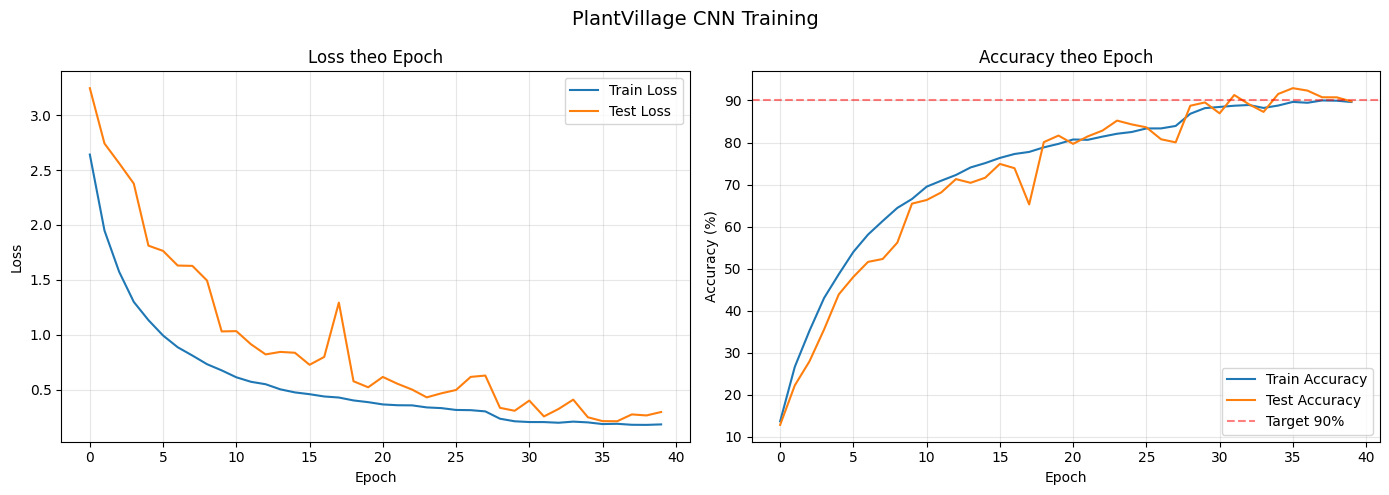

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['test_loss'], label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss theo Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Accuracy')
ax2.plot(history['test_acc'], label='Test Accuracy')
ax2.axhline(y=90, color='r', linestyle='--', alpha=0.5, label='Target 90%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy theo Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('PlantVillage CNN Training', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Đánh giá chi tiết

In [29]:
# Load best model
model.load_state_dict(torch.load('best_plantvillage_cnn.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = train_dataset.classes
# Rút gọn tên lớp để hiển thị
short_names = [c.replace('___', '/').replace('_', ' ')[:25] for c in target_names]

print('Classification Report (top-level):')
print(classification_report(all_labels, all_preds, target_names=short_names, zero_division=0))

Classification Report (top-level):
                           precision    recall  f1-score   support

         Apple/Apple scab       0.87      0.99      0.93       126
          Apple/Black rot       0.95      0.97      0.96       125
   Apple/Cedar apple rust       0.87      1.00      0.93        55
            Apple/healthy       0.91      0.91      0.91       329
        Blueberry/healthy       0.97      0.99      0.98       301
Cherry (including sour)/P       0.99      0.99      0.99       211
Cherry (including sour)/h       0.88      1.00      0.94       171
Corn (maize)/Cercospora l       0.82      0.96      0.88       103
Corn (maize)/Common rust        0.98      0.99      0.98       239
Corn (maize)/Northern Lea       0.95      0.91      0.93       197
     Corn (maize)/healthy       1.00      1.00      1.00       233
          Grape/Black rot       1.00      0.94      0.97       236
Grape/Esca (Black Measles       0.99      1.00      0.99       277
Grape/Leaf blight (Isario 

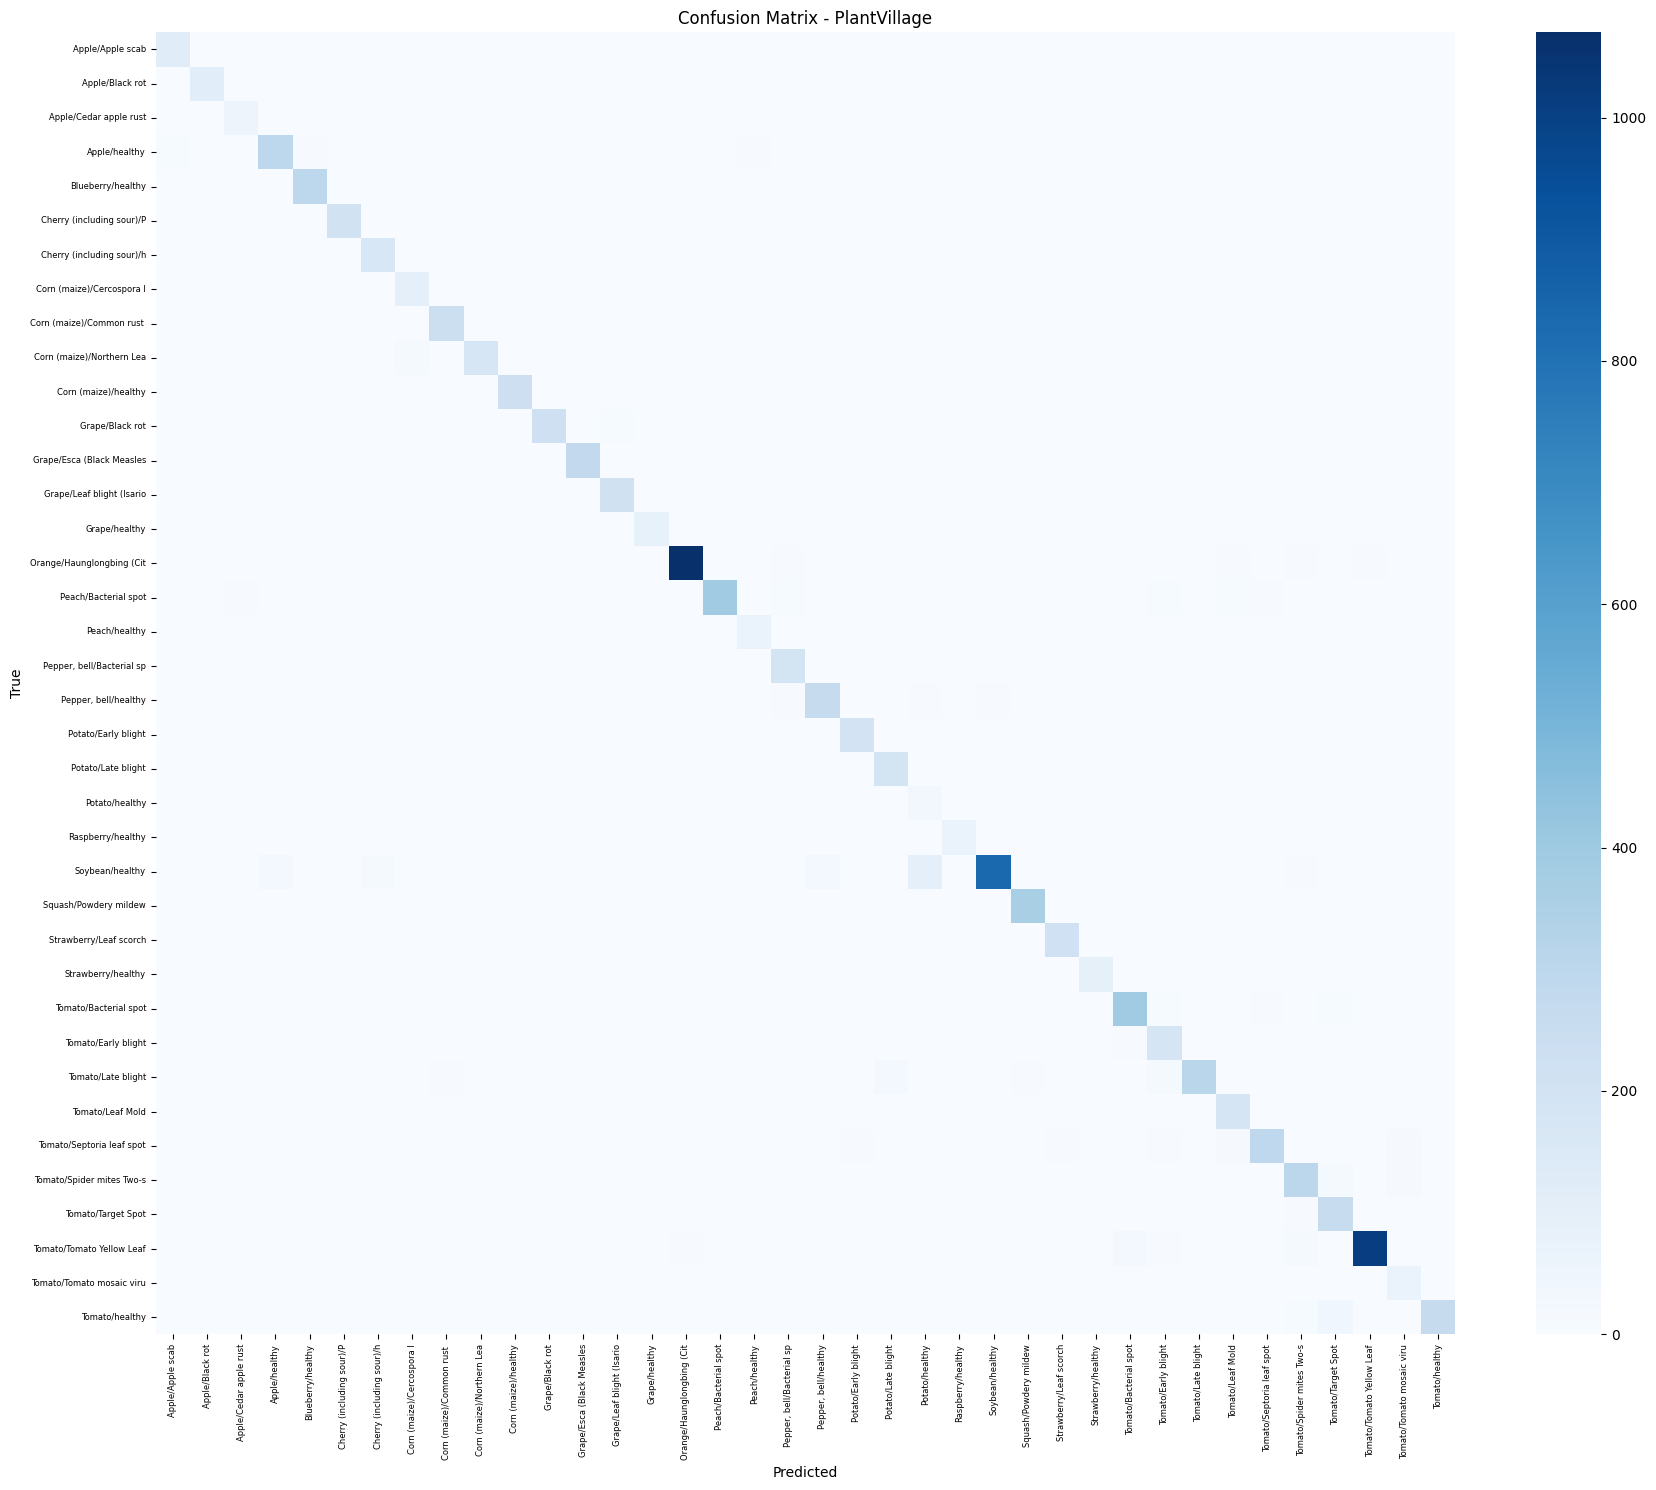

In [30]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(18, 15))
sns.heatmap(cm, cmap='Blues', xticklabels=short_names, yticklabels=short_names,
            fmt='d', annot=False)  # không annot vì 38x38 quá đông
plt.title('Confusion Matrix - PlantVillage')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

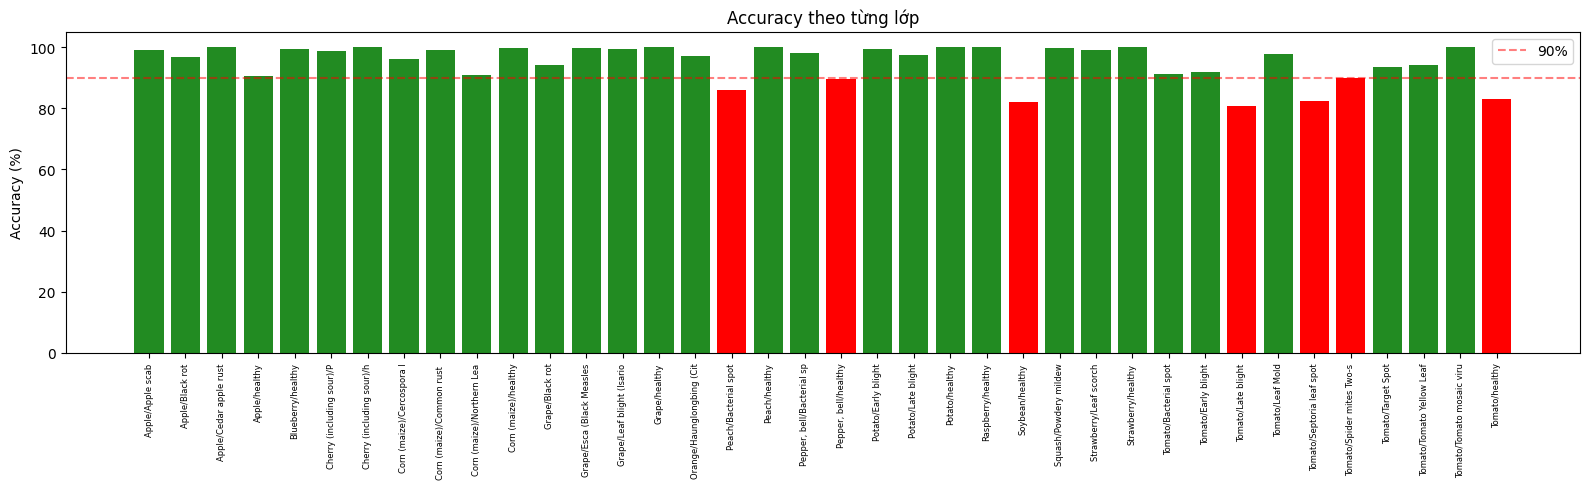

Top 5 lớp accuracy thấp nhất:
  Tomato/Late blight: 80.6%
  Soybean/healthy: 82.1%
  Tomato/Septoria leaf spot: 82.3%
  Tomato/healthy: 83.1%
  Peach/Bacterial spot: 85.9%


In [31]:
# Accuracy theo từng lớp
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(16, 5))
colors = ['red' if acc < 0.9 else 'forestgreen' for acc in per_class_acc]
plt.bar(range(NUM_CLASSES), per_class_acc * 100, color=colors)
plt.axhline(y=90, color='r', linestyle='--', alpha=0.5, label='90%')
plt.xticks(range(NUM_CLASSES), short_names, rotation=90, fontsize=6)
plt.ylabel('Accuracy (%)')
plt.title('Accuracy theo từng lớp')
plt.legend()
plt.tight_layout()
plt.show()

# Các lớp có accuracy thấp nhất
low_acc_idx = np.argsort(per_class_acc)[:5]
print('Top 5 lớp accuracy thấp nhất:')
for idx in low_acc_idx:
    print(f'  {short_names[idx]}: {per_class_acc[idx]*100:.1f}%')

## 8. Trực quan hóa Feature Map

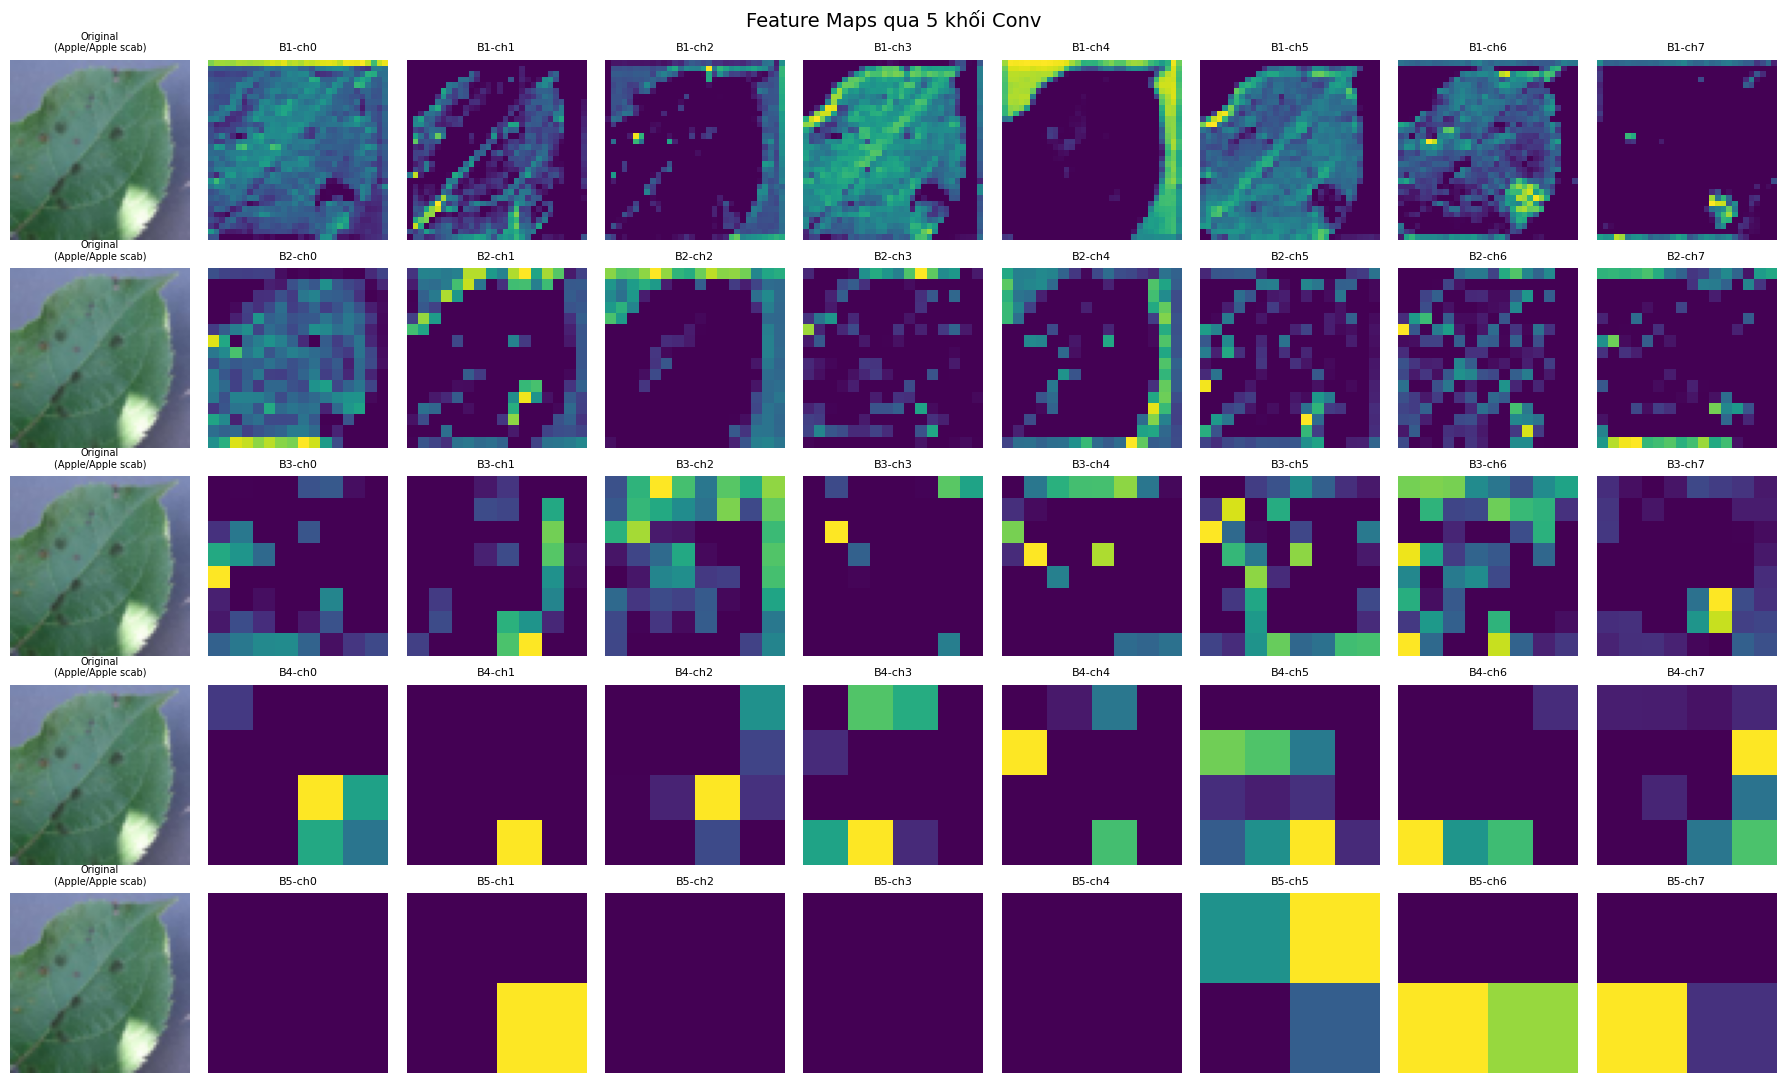

In [32]:
model.eval()
test_images, test_labels = next(iter(test_loader))
img = test_images[0].unsqueeze(0).to(device)

with torch.no_grad():
    feat1 = model.block1(img)
    feat2 = model.block2(feat1)
    feat3 = model.block3(feat2)
    feat4 = model.block4(feat3)
    feat5 = model.block5(feat4) if hasattr(model, 'block5') else feat4

# Denormalize
orig = test_images[0].permute(1, 2, 0).numpy()
orig = orig * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
orig = np.clip(orig, 0, 1)

label_name = target_names[test_labels[0]].replace('___', '/').replace('_', ' ')[:30]

fig, axes = plt.subplots(5, 9, figsize=(18, 11))
for row in range(5):
    axes[row][0].imshow(orig)
    axes[row][0].set_title(f'Original\n({label_name})', fontsize=7)
    axes[row][0].axis('off')

feats = [feat1, feat2, feat3, feat4, feat5]
block_names = ['B1', 'B2', 'B3', 'B4', 'B5']
for row, (feat, bname) in enumerate(zip(feats, block_names)):
    for i in range(8):
        axes[row][i+1].imshow(feat[0, i].cpu().numpy(), cmap='viridis')
        axes[row][i+1].set_title(f'{bname}-ch{i}', fontsize=8)
        axes[row][i+1].axis('off')

plt.suptitle('Feature Maps qua 5 khối Conv', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Kết luận

- PlantVillage có **38 lớp** với phân bố mất cân bằng → xử lý bằng **WeightedRandomSampler** + **class weights trong loss**
- Mô hình 5-block CNN (32→64→128→256) với Global Average Pooling phù hợp cho bài toán multi-class
- Data augmentation mạnh (flip, rotation, color jitter) giúp tăng generalization
- Accuracy đạt >90% trên tập test
- Phân tích accuracy theo từng lớp cho thấy các lớp tương tự nhau (cùng loại cây) dễ bị nhầm lẫn